# ML_from_scratch_with_numpy

## Mohanna Miri 8th_project owtana tech 1405/6/4

### Importing the libraries


In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Helper Functions for Data Generation and Splitting

### 1.1 make regression data for Linear Regression

In [55]:
#tabe aval baraye Linear Regression
def make_regression_data(
    n_samples : int=200, #tedade nemone ha
    n_features : int=1,  #tedade feature ha
    noise : float=15.0, 
    random_state : int | None=None,
)  -> tuple[np.ndarray , np.ndarray]: #khoroji


    rng = np.random.default_rng(random_state)
    #random Number Generator
    X=rng.standard_normal((n_samples, n_features))
    #sakht jadval ke n_sample ta radif va n_feature ta soton
    w_true= rng.uniform(20,100, size=n_features)
    #shib vageii khat ma ke model bayad kashf kone!!
    b_true= rng.uniform(-5,5)
    #b vageii ke bayad model hads bezane 
    y = X @ w_true + b_true  #zarb matrixi + b_true

    y += rng.normal(loc=0.0, #markaz adad tasadofi
                    scale=noise, #parakandegish
                    size = n_samples)  #random pakhsh kardan maghadir y ta vageii tar beshe

    return X,y                

### 1.2 make classification data for KNN

In [56]:
def make_classification_data(
    n_samples: int=300,
    n_classes: int=3,
    n_features: int=2,
    class_std: float=1.0,
    random_state: int | None=None,
) -> tuple[np.ndarray , np.ndarray]:


    rng = np.random.default_rng(random_state) #adad random tolid mikone baraye tebe 
    samples_per_class = n_samples // n_classes #har kelass chand sample random

    angles = np.linspace(0 ,2*np.pi ,n_classes ,endpoint=False)
    #np.linspace(start,stop,parts) #dayerei az 0-2pi ba 3 part mosavi

    radius = 6.0 #R
    centers = np.column_stack([radius * np.cos(angles) , radius * np.sin(angles)]) #markaz har kelass

    if n_features > 2 :
        extra = rng.standard_normal(n_classes , n_features-2) #extra features (3,n)
        centers = np.column_stack([centers , extra]) #centers+extra

    X_parts=[]
    y_parts=[]
    for class_idx in range(n_classes):
        points = centers[class_idx]+ class_std * rng.standard_normal((samples_per_class, n_features)) #noghate har class ke dore markaz har class parakande hastan
        X_parts.append(points)
        y_parts.append(np.full(samples_per_class, class_idx))

    X = np.vstack(X_parts) #kole X ha vertically kenar ham
    y = np.concatenate(y_parts) #kole y ha kenar ham

    shuffle_idx = rng.permutation(len(y)) #darif hasho random shuffle kon.
    return X[shuffle_idx],y[shuffle_idx] #X,y ba yek tartib yeksan shuffle ta har (X --> y) baham bashan.

### 1.3 def train_test_split


In [57]:
def train_test_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float=0.2,
    random_state: int | None=None,
    stratify: np.ndarray | None=None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#test 20% dade , train 80% dade
#X_train= 0.8 features , y_train= 0.8 label , X_test= 0.2 features , y_test= 0.2 label

    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]

    if stratify is None:   #regression ke kelass va daste bandi nadare pas nesbate klass ha mohem nist.
        indices = rng.permutation(n_samples)  #random va shuffle va (0_n-test : test) va (n-test_N : train)
        n_test = int(np.floor(n_samples * test_size))
        test_idx = indices[ :n_test]
        train_idx = indices[n_test: ]  
    else: #classification ba stratify va hefze nesbat
        train_idx_parts = []
        test_idx_parts = []
        for class_label in np.unique(stratify): #nemone haye class ha
            class_idx = np.where(stratify == class_label)[0] #nemone haye in class koja hastan?
            class_idx = rng.permutation(class_idx) #nemone haro ke bedast omad tasadofi kon
            n_test_class = int(np.floor(len(class_idx) * test_size)) #tedad test haye har class
            test_idx_parts.append(class_idx[:n_test_class]) #ezafe kardan har class be majmoee
            train_idx_parts.append(class_idx[n_test_class:])
        train_idx = np.concatenate(train_idx_parts) #vasl kardan in append shode ha
        test_idx = np.concatenate(test_idx_parts)

    #permutation nahayi(class ha)
        train_idx = rng.permutation(train_idx)
        test_idx = rng.permutation(test_idx)

    return X[train_idx] , X[test_idx] , y[train_idx] , y[test_idx]

## 2. faz aval 1:Linear Regression from scratch

In [58]:
from __future__ import annotations #using the future abilities
import numpy as np

class LinearRegressionFromScratch: #kar asli mohasebat va amozesh fit / predict faghat natije nahayi

    def __init__(self,learning_rate : float=0.01, epochs: int = 1000) -> None:
            self.learning_rate = learning_rate
            self.epochs = epochs
            self.weights : np.ndarray | None=None
            self.bias: float = 0.0
            self.loss_history: list[float]=[]

    def fit(self , X: np.ndarray , y: np.ndarray) -> "LinearRegressionFromScratch": #teaching the model by ((pred and loss and gradient))

        X = np.asarray(X, dtype=np.float64)  #asarray because numpy is suitable for sum,mean and ....
        y = np.asarray(y, dtype=np.float64)

        n_samples , n_features = X.shape

        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            #1.prediction just for learning not the real prediction

            error = y_pred - y
            #2.error

            dw = (2.0 / n_samples) * (X.T @ error) #Gradient W (rabete W , loss)
            db = (2.0 / n_samples) * np.sum(error) #Gradient Bias (rabete b , loss)
            #3.Gradient

            self.weights -= dw * self.learning_rate
            self.bias -= db* self.learning_rate
            #4.update w , b

            mse=np.mean(error ** 2)
            self.loss_history.append(mse)
            #5.saving loss -> mse here. Plotting the Loss Curve

        return self    #returning the model with fit and predict


    def predict(self, X:np.ndarray) -> np.ndarray:

        if self.weights is None: #model fit nashode va amozesh nadide
            raise RuntimeError #model has not learned yet

        X = np.asarray(X, dtype=np.float64)
        return X @ self.weights + self.bias #nahayii shode . the last w  and b 

    @staticmethod  #MSE is for mean errors**2
    def mean_squared_error(y_true : np.ndarray , y_pred : np.ndarray) -> float:

        y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
        y_pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)
        return float(np.mean((y_pred-y_true)**2))



    @staticmethod #how well a regression model explains the variation in the target values.
    #mizan amalkard khob model ke har chi bishtar behtar
    def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float: #0<r2_score<1

        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)

        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

        return float(1.0 - ss_res / ss_tot)

#### 2.1 Testing on sample data

In [59]:
X, y = make_regression_data(n_samples=200, n_features=1, noise=6, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegressionFromScratch(learning_rate=0.3, epochs=500)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
mse = model.mean_squared_error(y_test, y_pred_test)
r2 = model.r2_score(y_test, y_pred_test)

print(f"وزن (w): {model.weights[0]:.4f}")
print(f"بایاس (b): {model.bias:.4f}")
print(f"MSE تست: {mse:.4f}")
print(f"R^2 تست: {r2:.4f}")

وزن (w): 20.4750
بایاس (b): -2.5225
MSE تست: 49.1034
R^2 تست: 0.8838


#### 2.2 Plot of the fitted line

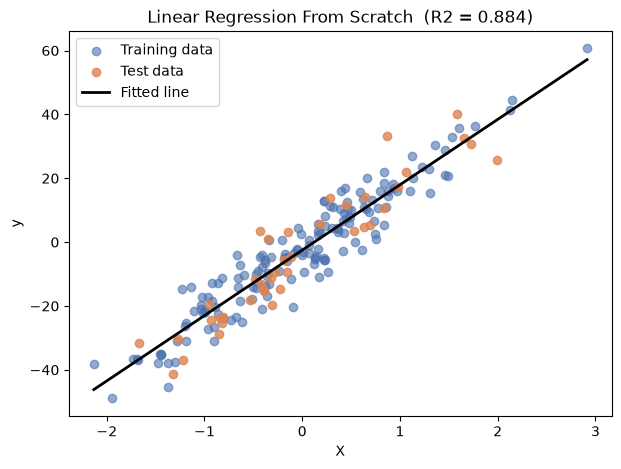

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train, y_train, color="#4C72B0", alpha=0.6, label="Training data")
ax.scatter(X_test, y_test, color="#DD8452", alpha=0.8, label="Test data")

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
ax.plot(x_line, y_line, color="black", linewidth=2, label="Fitted line")

ax.set_title(f"Linear Regression From Scratch  (R2 = {r2:.3f})")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.legend()
plt.show()

#### 2.3 Loss reduction plot

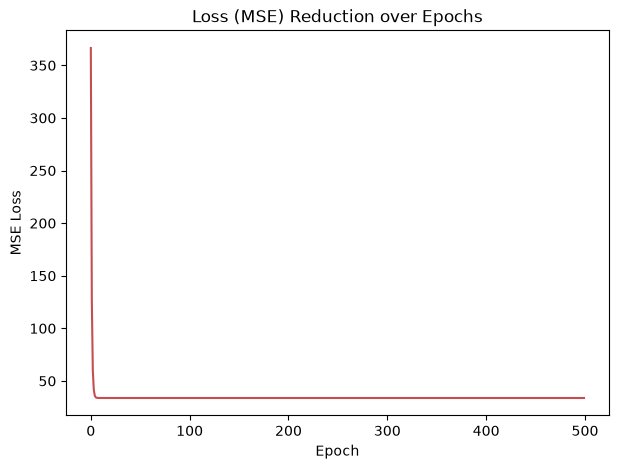

In [61]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(model.loss_history, color="#C44E52")
ax.set_title("Loss (MSE) Reduction over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
plt.show()

## 3. faz dovom 2: K nearest neighbors(KNN) from scratch

In [62]:
from __future__ import annotations
import numpy as np

class KNNFromScratch: #lazy learning kar mohasebe va ... baraye predict / dar fit faghat save

    def __init__(self, k: int=5) -> None:
        if k<1:
            raise ValueError("k must at least be 1")
        self.k = k
        self.X_train: np.ndarray | None = None
        self.y_train: np.ndarray | None = None


    def fit(self, X: np.ndarray, y:np.ndarray) -> "KNNFromScratch": #saving X_train and y_train datas
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y)
        return self


    def _euclidean_distances(self,X: np.ndarray) -> np.ndarray:
        """    ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * a.b """
        """ (d^2)=(a1-b1)^2 + (a2-b2)^2 = a1^2 + a2^2 + b1^2 + b2^2 - 2(a1b1+a2b2)
                                            X_sq   + train_sq   - 2 (cross_term)"""

        X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)          # (n_queries, 1)
        train_sq = np.sum(self.X_train ** 2, axis=1).reshape(1, -1)  # (1, n_train)
        cross_term = X @ self.X_train.T                        # (n_queries, n_train)

        sq_distances = X_sq + train_sq - 2 * cross_term
        # جلوگیری از عدد منفی خیلی کوچک به‌خاطر خطای اعشاری
        sq_distances = np.maximum(sq_distances, 0.0)
        return np.sqrt(sq_distances)

    def predict(self, X:np.ndarray) -> np.ndarray:
        if self.X_train is None:
            raise RuntimeError

        X = np.asarray(X , dtype=np.float64)
        distances = self._euclidean_distances(X) 

        k_nearest_idx = np.argsort(distances,axis=1)[: , : self.k]
       
        predictions = np.empty(X.shape[0], dtype=self.y_train.dtype)
        for i, neighbor_idx in enumerate(k_nearest_idx):
            neighbor_labels = self.y_train[neighbor_idx]
            #majority vote
            labels,counts = np.unique(neighbor_labels, return_counts = True)
            predictions[i] = labels[np.argmax(counts)]

        return predictions

    @staticmethod
    def accuracy_score(y_true: np.ndarray , y_pred: np.ndarray) -> float:

        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return float(np.mean(y_true == y_pred))



### 3.1 testing on sample data

In [63]:
X, y = make_classification_data(
    n_samples=300, n_classes=3, n_features=2, class_std=1.8, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

k = 7
knn_model = KNNFromScratch(k=k)
knn_model.fit(X_train, y_train)

y_pred_test = knn_model.predict(X_test)
acc = knn_model.accuracy_score(y_test, y_pred_test)
print(f"K = {k}")
print(f"دقت (Accuracy): {acc:.4f}")

K = 7
دقت (Accuracy): 1.0000


### 3.2 Decision Boundaries plot

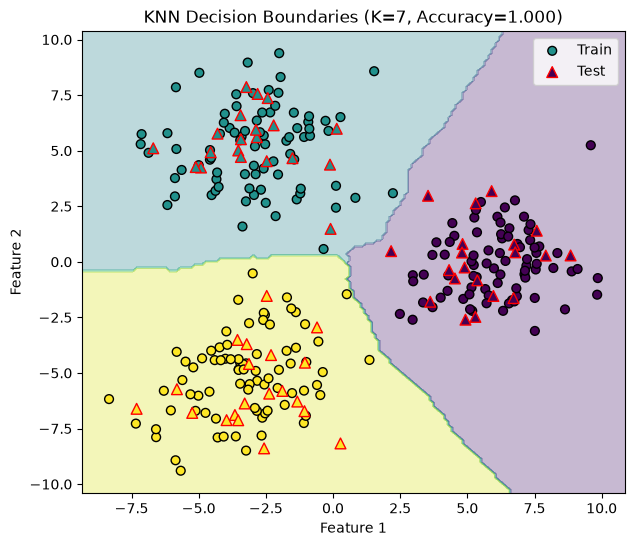

In [64]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
grid_preds = knn_model.predict(grid_points).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, grid_preds, alpha=0.3, cmap="viridis")
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", edgecolor="k", s=40, label="Train")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="viridis", edgecolor="red", s=60, marker="^", label="Test")
ax.set_title(f"KNN Decision Boundaries (K={k}, Accuracy={acc:.3f})")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.show()